In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
from pathlib import Path

# RESULTS = Path('../results')
RESULTS = Path('../results/NEW_DATA')
DOMAINS = ['synthetic', 'lightbox', 'sunlamp']
DOMAIN_COLORS = {'synthetic': '#4C72B0', 'lightbox': '#DD8452', 'sunlamp': '#55A868'}

# correlate each feature against the two pose-error components separately
COMPONENTS = {'E_R': 'rotation error  [deg]', 'E_T': 'translation error  [m]'}

# feature_names = np.load(RESULTS / 'img_stats_feature_names.npy', allow_pickle=True).tolist()
feature_names = np.load(RESULTS / 'model_feature_names.npy', allow_pickle=True).tolist()


def load_features_and_errors(domain):
    # X = np.load(RESULTS / f'img_stats_{domain}.npy')
    X = np.load(RESULTS / f'model_features_{domain}.npy')
    df = pd.read_csv(RESULTS / f'per_image_errors_{domain}.csv')
    n = min(len(X), len(df))
    errors = {comp: df[comp].values[:n] for comp in COMPONENTS}
    return X[:n], errors

print(f'{len(feature_names)} features: {feature_names}')


13 features: ['disagree_R_deg', 'disagree_t_m', 'disagree_t_norm', 'seg_entropy', 'hm_entropy_mean', 'hm_peak_mean', 'hm_peak_min', 'hm_nconf', 'effi_cls', 'reject', 'target_distance', 'bbox_area', 'bbox_aspect']


In [2]:
# Spearman rho between each feature and each error component, per domain.
# rho_table[comp][domain] -> (n_features,) array
rho_table  = {comp: {} for comp in COMPONENTS}
pval_table = {comp: {} for comp in COMPONENTS}

for domain in DOMAINS:
    X, errors = load_features_and_errors(domain)
    for comp in COMPONENTS:
        err = errors[comp]
        rhos, pvals = [], []
        for j in range(X.shape[1]):
            rho, pval = spearmanr(X[:, j], err)
            rhos.append(rho)
            pvals.append(pval)
        rho_table[comp][domain]  = np.array(rhos)
        pval_table[comp][domain] = np.array(pvals)

# Print summary, one table per component
for comp, comp_label in COMPONENTS.items():
    df_rho = pd.DataFrame(rho_table[comp], index=feature_names)
    df_rho.index.name = 'feature'
    print(f'\nSpearman ρ (feature vs {comp_label}):')
    print(df_rho.round(3).to_string())



Spearman ρ (feature vs rotation error  [deg]):
                 synthetic  lightbox  sunlamp
feature                                      
disagree_R_deg      -0.046     0.007    0.076
disagree_t_m         0.194     0.234    0.159
disagree_t_norm      0.036     0.178    0.117
seg_entropy         -0.222     0.072    0.003
hm_entropy_mean     -0.091     0.200    0.150
hm_peak_mean        -0.074    -0.279   -0.173
hm_peak_min         -0.010    -0.216   -0.115
hm_nconf             0.027    -0.163   -0.134
effi_cls             0.008    -0.206   -0.156
reject                 NaN     0.016    0.018
target_distance      0.312     0.123    0.098
bbox_area           -0.256    -0.107   -0.114
bbox_aspect         -0.004    -0.006    0.005

Spearman ρ (feature vs translation error  [m]):
                 synthetic  lightbox  sunlamp
feature                                      
disagree_R_deg       0.044     0.068    0.167
disagree_t_m         0.590     0.599    0.558
disagree_t_norm      0.432   

/var/folders/sv/4y94qp_x2c53cgsg_2b0kcxc0000gn/T/ipykernel_81252/1506489305.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(X[:, j], err)


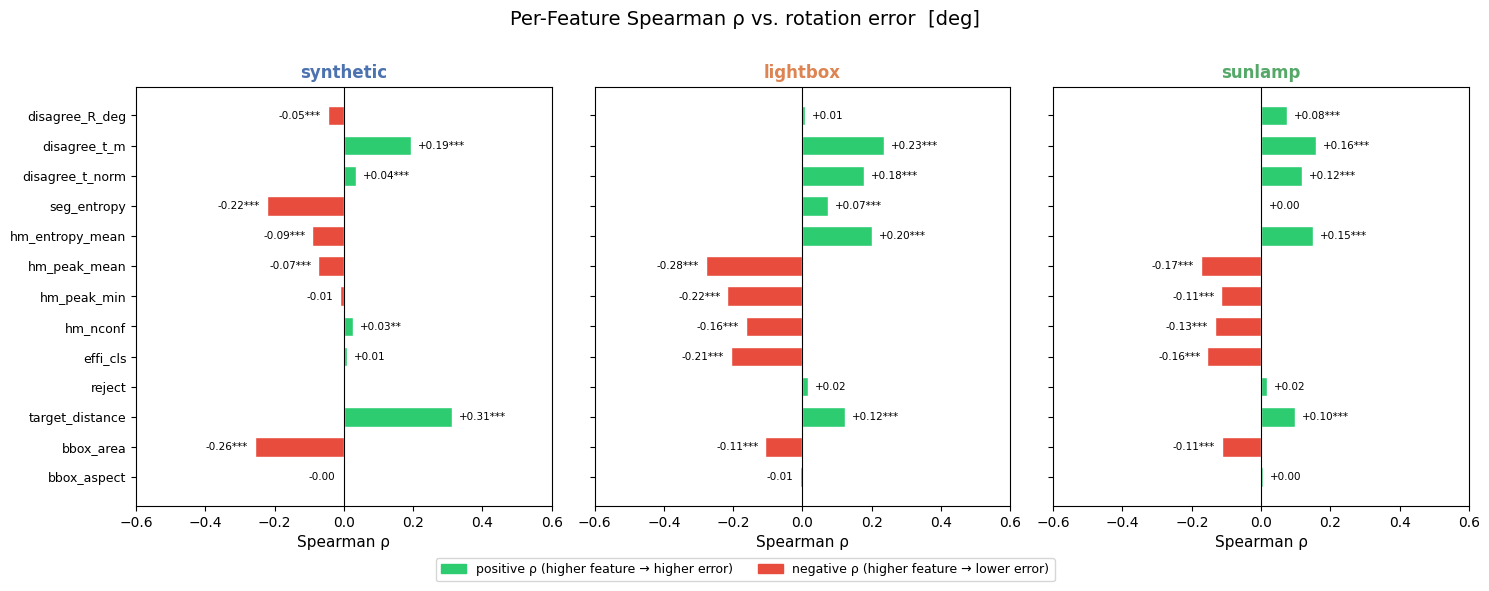

Saved → figures/feature_E_R_correlation.png


In [3]:
# Horizontal bar chart per error component: one subplot per domain
# Bars colored green (positive rho) or red (negative rho)
# Stars mark significance: * p<0.05, ** p<0.01, *** p<0.001

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''


def plot_feature_correlation(comp):
    """One figure (3 domain subplots) of per-feature Spearman ρ vs. the given component."""
    comp_label = COMPONENTS[comp]
    n_feat = len(feature_names)
    y_pos  = np.arange(n_feat)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
    fig.suptitle(f'Per-Feature Spearman ρ vs. {comp_label}', fontsize=14, y=1.01)

    for ax, domain in zip(axes, DOMAINS):
        rhos  = rho_table[comp][domain]
        pvals = pval_table[comp][domain]
        colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in rhos]

        ax.barh(y_pos, rhos, color=colors, edgecolor='white', height=0.65)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlim(-0.6, 0.6)
        ax.set_xlabel('Spearman ρ', fontsize=11)
        ax.set_title(domain, fontsize=12, color=DOMAIN_COLORS[domain], fontweight='bold')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(feature_names, fontsize=9)
        ax.invert_yaxis()

        # annotate rho value + significance stars to the right of each bar
        for i, (rho, pval) in enumerate(zip(rhos, pvals)):
            label = f'{rho:+.2f}{sig_stars(pval)}'
            x_off = 0.02 if rho >= 0 else -0.02
            ha    = 'left' if rho >= 0 else 'right'
            ax.text(rho + x_off, i, label, va='center', ha=ha, fontsize=7.5)

    pos_patch = mpatches.Patch(color='#2ecc71', label='positive ρ (higher feature → higher error)')
    neg_patch = mpatches.Patch(color='#e74c3c', label='negative ρ (higher feature → lower error)')
    fig.legend(handles=[pos_patch, neg_patch], loc='lower center', ncol=2,
               fontsize=9, bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    out = f'../figures/feature_{comp}_correlation.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/feature_{comp}_correlation.png')


# Rotation error
plot_feature_correlation('E_R')


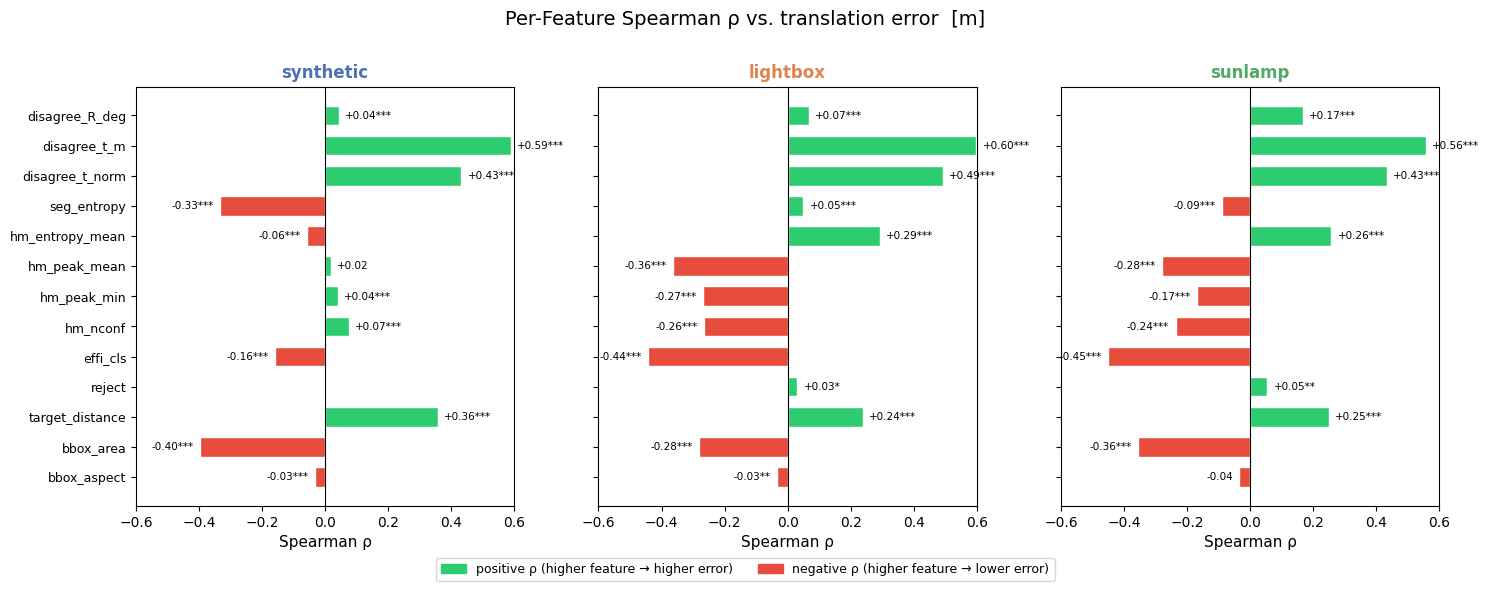

Saved → figures/feature_E_T_correlation.png


In [4]:
# Translation error
plot_feature_correlation('E_T')